# 10. Precision, Recall and F1 Score

These three metrics answer three different questions.

* **Accuracy:** Overall, how often is the model correct?
* **Precision:** When the model predicts Positive, how often is it correct?
* **Recall:** Of all actual Positive cases, how many did the model find?
* **F1 Score:** A balance between Precision and Recall.

---

# Why do we need them?

Consider Cancer Detection.

Suppose

1000 patients

* 990 Healthy
* 10 Cancer

Model predicts everyone is Healthy.

Accuracy

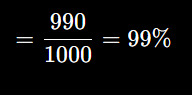

Amazing?

No.

The model detected

0

cancer patients.

Accuracy hides this problem.

So we need better metrics.

---

# 1. Precision

## Theory

Precision answers:

> **Whenever my model predicts Positive, how often is it actually correct?**

Imagine

The model predicted

50

patients have cancer.

Actually,

40

really had cancer.

10

were healthy.

Then

Precision

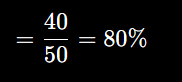

Meaning

Among all positive predictions,

80%

were correct.

---

## Formula

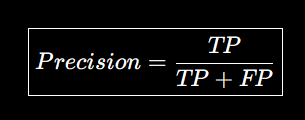

Notice

Prediction Positive means

TP

or

FP

---

## Why?

Because

Positive predictions consist of

* True Positive
* False Positive

Nothing else.

---

## Intuition

Suppose

Spam Filter

Model marked

100

emails as spam.

Actually

95

were spam.

5

were important emails.

Precision

**`95%`**

Very good.

---

High Precision means

Few False Positives.

---

# Memory Trick

Precision asks

> **"Can I trust the model when it says Positive?"**

---

# 2. Recall

## Theory

Recall answers

> **Out of all actual Positive cases, how many did the model detect?**

Suppose

100

patients actually have cancer.

Model found

90.

Missed

10.

Recall

**`90%`**

---

## Formula

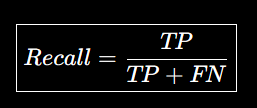

---

Why?

Actual Positive consists of

* TP
* FN

Nothing else.

---

## Intuition

Suppose

100

spam emails arrived.

Model found

95.

Missed

5.

Recall

**`95%`**

---

High Recall means

Few False Negatives.

---

# Memory Trick

Recall asks

> **"How many actual Positive cases did I recall (find)?"**

---

# Precision vs Recall

This is one of the most important concepts.

---

### Precision

Focuses on

Predicted Positives.

```text id="r3kmyk"
Model says Positive

↓

How often is it correct?
```

---

### Recall

Focuses on

Actual Positives.

```text id="8yid6t"
Actually Positive

↓

Did the model find it?
```

---

# Example

Suppose

|    | Count |
| -- | ----: |
| TP |    80 |
| FP |    20 |
| FN |    10 |
| TN |    90 |

---

Precision

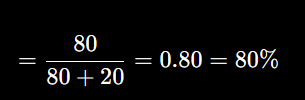

---

Recall

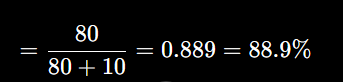

---

# Which One is More Important?

Depends on the application.

---

## High Precision Needed

Email Spam

If the model says

Spam,

it should really be spam.

Otherwise,

important emails may go to spam.

---

High Precision.

---

## High Recall Needed

Cancer Detection

Missing cancer

(False Negative)

is dangerous.

So we want

Very High Recall.

Even if some healthy patients are mistakenly flagged.

---

# Precision–Recall Tradeoff

Suppose

Threshold

0.5

Current

Precision

90%

Recall

75%

---

Now decrease threshold

to

0.2

Model predicts

Positive more often.

Result

Recall increases.

But

Precision decreases.

---

This tradeoff exists in almost every classifier.

---

# 3. F1 Score

Now suppose

Model A

Precision

100%

Recall

20%

---

Model B

Precision

70%

Recall

70%

---

Which is better?

Hard to decide.

So we combine them into

F1 Score.

---

## Formula

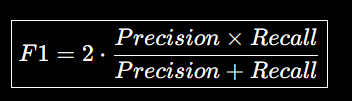

This is called the **Harmonic Mean**.

---

# Why Harmonic Mean?

Why not

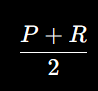

Because the arithmetic mean can hide poor performance.

Example

Precision

100%

Recall

0%

Arithmetic Mean

50%

Looks acceptable.

But the model found **none** of the actual positive cases.

The Harmonic Mean penalizes such imbalance.

---

Example

Precision

1

Recall

0

F1

**`0`**

Perfect.

---

Another example

Precision

0.8

Recall

0.9

F1

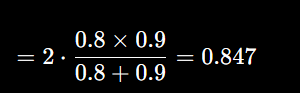

---

# Python Implementation

```python
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

actual = [1,1,0,0,1,0]
predicted = [1,0,0,1,1,0]

print(precision_score(actual,predicted))
print(recall_score(actual,predicted))
print(f1_score(actual,predicted))
```

---

# One Complete Example

Suppose

|    | Count |
| -- | ----: |
| TP |    40 |
| FP |    10 |
| FN |    20 |
| TN |   130 |

---

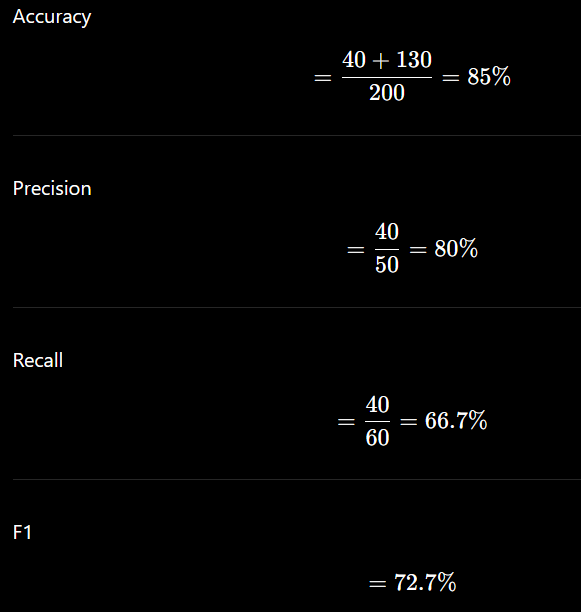

Notice

Even though Accuracy is

85%

Recall is much lower.

This tells us

The model is missing many positive cases.

---

# Summary Table

| Metric    | Formula                     | Question it Answers                                            |
| --------- | --------------------------- | -------------------------------------------------------------- |
| Accuracy  | (\frac{TP+TN}{TP+TN+FP+FN}) | Overall, how often is the model correct?                       |
| Precision | (\frac{TP}{TP+FP})          | When the model predicts Positive, how often is it correct?     |
| Recall    | (\frac{TP}{TP+FN})          | Out of all actual Positive cases, how many did the model find? |
| F1 Score  | (2\frac{PR}{P+R})           | What is the balance between Precision and Recall?              |

---

# Easy Memory Trick

* **Precision** → Think **Predicted Positive**.

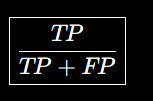

  > "When I predict Positive, am I usually right?"

---

* **Recall** → Think **Real (Actual) Positive**.

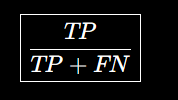

  > "Of all the actual Positive cases, how many did I catch?"

---

* **F1 Score** → Think **Balance**.

  > "I want both Precision and Recall to be high."

# Method 1: Change the Decision Threshold (Most Common)

By default, Logistic Regression predicts:

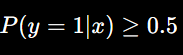

↓

Predict class 1.

But **0.5 is just a default**. You can choose a different threshold.

---

## Increase Precision

Suppose you change the threshold to

**0.9**

Now the model predicts Positive **only when it's very confident**.

Example:

| Probability | Threshold = 0.5 | Threshold = 0.9 |
| ----------- | --------------- | --------------- |
| 0.55        | Positive        | Negative        |
| 0.82        | Positive        | Negative        |
| 0.96        | Positive        | Positive        |

Result:

* ✅ Fewer False Positives
* ✅ Higher Precision
* ❌ Lower Recall (you miss more actual positives)

---

## Increase Recall

Lower the threshold.

Example:

[
0.2
]

| Probability | Threshold = 0.5 | Threshold = 0.2 |
| ----------- | --------------- | --------------- |
| 0.25        | Negative        | Positive        |
| 0.40        | Negative        | Positive        |
| 0.95        | Positive        | Positive        |

Result:

* ✅ More actual positives detected
* ✅ Higher Recall
* ❌ More False Positives
* ❌ Lower Precision

---

# Why does this happen?

Imagine cancer detection.

Threshold = **0.9**

Only patients with 90% or higher probability are predicted as having cancer.

Many cancer patients with probabilities like

0.75

or

0.65

will be missed.

Recall decreases.

---

Threshold = **0.2**

Almost every suspicious patient is predicted as having cancer.

Very few cancer patients are missed.

Recall increases.

But many healthy people are also predicted as having cancer.

Precision decreases.

---

# Method 2: Better Features

Suppose your model only uses:

* Age

Prediction quality won't be great.

Now add:

* Blood Pressure
* Sugar Level
* BMI
* Family History

The model gets more information.

Often **both Precision and Recall improve** because the classifier separates classes better.

---

# Method 3: More Training Data

If the dataset is small,

the model may not learn the true pattern.

Adding more good-quality data often improves both metrics.

---

# Method 4: Handle Class Imbalance

Suppose

990 Healthy

10 Cancer

The model tends to predict "Healthy" because that minimizes the overall error.

Techniques like:

* Oversampling
* Undersampling
* Class weights

help the model pay more attention to the minority class, often improving Recall.

---

# Method 5: Better Model

Instead of Logistic Regression,

try:

* Decision Tree
* Random Forest
* XGBoost
* Neural Network

Sometimes a more expressive model improves both Precision and Recall.

---

# Precision–Recall Trade-off

The threshold is the main reason you usually can't maximize both simultaneously.

```text
Threshold ↑

Precision ↑

Recall ↓
```

and

```text
Threshold ↓

Precision ↓

Recall ↑
```

---

# Which should you optimize?

| Application      | Priority       | Reason                                                                                  |
| ---------------- | -------------- | --------------------------------------------------------------------------------------- |
| Cancer Detection | High Recall    | Missing a patient (FN) is dangerous.                                                    |
| Fraud Detection  | High Recall    | Better to investigate extra transactions than miss fraud.                               |
| Spam Filter      | High Precision | Don't send important emails to spam.                                                    |
| Face Unlock      | High Precision | Don't let the wrong person unlock the phone.                                            |
| Search Engine    | High Recall    | Users usually prefer seeing all relevant results, even with some extra irrelevant ones. |


### **But it doesnt change our prediction wirtie it just an score we are maupulating to be shown?**

The answer is:

> **Yes. F1, F2, F3, Precision, Recall, and Accuracy do NOT change the model's predictions. They are only evaluation metrics.**

They are **not used during training**.

---

## During Training

The model learns using:

```text
Prediction
      ↓
Cross Entropy Loss
      ↓
Gradient
      ↓
Update w,b
```

Notice that **F1 is nowhere here**.

The model never says:

> "Oh, my F1 is low, let me change my weights."

It doesn't know what F1 is.

---

## After Training

Suppose the model predicts:

| Actual | Prediction |
| ------ | ---------- |
| 1      | 1          |
| 1      | 0          |
| 0      | 1          |
| 0      | 0          |

Now we compute:

* Accuracy
* Precision
* Recall
* F1
* F2
* F0.5

These are just **reports**.

They tell us how well the already-trained model performed.

---

# Then why do people care about F2 or F3?

Because **they help humans choose the model or threshold**.

Suppose you trained three models.

| Model | Precision | Recall |  F2 |
| ----- | --------: | -----: | --: |
| A     |       95% |    60% | 68% |
| B     |       88% |    90% | 89% |
| C     |       75% |    98% | 93% |

If you're building a cancer detection system, you might choose **Model C** because F2 gives more importance to Recall.

The model itself doesn't change.

**You** decide which model is best based on the metric.

---

# What actually changes predictions?

Only things like:

* Changing the **decision threshold** (e.g., 0.5 → 0.3)
* Retraining with different data
* Better features
* Different algorithms
* Different learned weights (w) and (b)

These can change predictions.

---

# What does NOT change predictions?

* Accuracy
* Precision
* Recall
* F1
* F2
* F0.5

These only **measure** performance.

---

# Think of it like an exam

Suppose you score:

* Math = 90
* Physics = 80
* Chemistry = 95

Now your teacher calculates:

* Average = 88.3%
* Grade = A
* Rank = 5

Did calculating the average or grade change your marks?

**No.**

Your marks stay the same.

The average and grade simply **describe** your performance.

Similarly:

```text
Predictions
      │
      ▼
Accuracy
Precision
Recall
F1
F2
```

These metrics only **describe** the predictions. They do not modify them.

---

### One small exception (important)

Although these metrics do **not directly** change predictions, they **can indirectly influence future models**.

For example:

* You evaluate a model using **F2**.
* You realize Recall is too low.
* You lower the classification threshold from **0.5 to 0.3** or retrain the model.

Now the predictions change—but **because you changed the model or threshold**, **not because F2 itself changed anything**.

So your statement is correct:

> **F1, F2, F3, Precision, Recall, and Accuracy are evaluation scores. They don't change the predictions; they help us evaluate and compare models or choose better settings.**


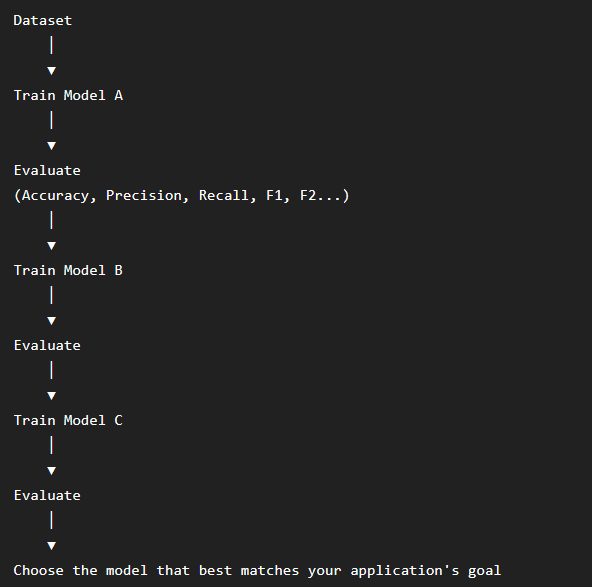